In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Open Meteo api call

In [ ]:
import requests
import pandas as pd
import json
from dotenv import load_dotenv
import os
import time
from pathlib import Path


# Load environment variables from .env file
load_dotenv()
# 1. SETUP YOUR CREDENTIALS
# This is the token you just provided
API_TOKEN = os.getenv("MET_OFFICE_API_KEY")

# 2. DEFINE THE REQUEST
# URL for Hourly Spot Data (Live Forecast)
url = "https://archive-api.open-meteo.com/v1/archive"

start_date = "2020-01-01"
end_date = "2025-12-31"

# Comprehensive UK Regional Coordinates for Weather API
# Includes England (spread), Scotland, Wales

uk_regions = {

    # --- SCOTLAND (Crucial for Wind) ---
    "Scot_Highlands":      [ 57.4778, -4.2247], # Inverness area
    "Scot_Aberdeenshire":  [ 57.1497, -2.0943], # Offshore wind hub
    "Scot_Glasgow_West":   [ 55.8642, -4.2518],
    "Scot_Edinburgh_East": [ 55.9533, -3.1883],
    "Scot_Borders":        [ 55.5486, -2.7861],

    # --- WALES ---
    "Wales_North_Gwynedd": [ 52.9370, -3.8960], # Mountainous/Windy
    "Wales_South_Cardiff": [ 51.4816, -3.1791],

    # --- ENGLAND NORTH ---
    "Eng_North_Tyne":      [ 55.0077, -1.6578], # Newcastle
    "Eng_North_Cumbria":   [ 54.8925, -2.9329], # West coast wind
    "Eng_Yorkshire":       [ 53.9590, -1.0873], # Drax area
    "Eng_Manchester":      [ 53.4808, -2.2426],

    # --- ENGLAND MIDLANDS ---
    "Eng_West_Midlands":   [ 52.4862, -1.8904], # Birmingham
    "Eng_East_Midlands":   [ 52.9548, -1.1581], # Nottingham

    # --- ENGLAND EAST (Wind & Solar) ---
    "Eng_East_Norfolk":    [ 52.6309, 1.2974],  # Bacton gas/wind
    "Eng_East_Suffolk":    [ 52.1732, 1.3513],  # Sizewell Nuclear/Wind

    # --- ENGLAND SOUTH ---
    "Eng_London":          [ 51.5074, -0.1278], # Main Load
    "Eng_South_Kent":      [ 51.2787, 0.5217],  # Interconnectors
    "Eng_South_Hampshire": [ 51.0577, -1.3187], # Southampton
    "Eng_South_Cornwall":  [ 50.2660, -5.0527], # Solar Hub
    "Eng_South_Bristol":   [ 51.4545, -2.5879]
}



# headers = {
#     "apikey": API_TOKEN,
#     "accept": "application/json"
# }

def get_region_data():
    return uk_regions

# 4. CHECK RESULTS
for key, location in uk_regions.items():
    print(f"📡 Fetching data for {key}...")

    params = {
        "latitude": location[0],
        "longitude": location[1],
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m,wind_speed_80m,shortwave_radiation,direct_normal_irradiance,cloud_cover",
        "timezone": "GMT" # Crucial for alignment
    }
    file_name = f"weather_{key}.csv"
    if Path("./data/" + file_name).exists():
        print('✅ Data already exists')
        continue

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()
        
        # Open-Meteo returns data directly in the 'hourly' key
        hourly_data = data['hourly']
        
        # Create DataFrame
        df = pd.DataFrame(hourly_data)
        
        # Save
        df.to_csv(f"./data/{file_name}", index=False)
        print(f"✅ Saved {len(df)} rows to ./data/{file_name}")
        
    else:
        print(f"❌ Error: {response.status_code}")
        print(response.text)
    
    # Polite sleep to respect the free API
    time.sleep(1.5)

print("\n🚀 All downloads complete.")

Correlation code

In [ ]:
import pandas as pd

# Correlate embedded solar generation with regional Solar_* features
INPUT_FILE = "final_model_data.csv"
OUTPUT_FILE = "embedded_solar_correlations.csv"

_df = pd.read_csv(INPUT_FILE, low_memory=False)

if "EMBEDDED_SOLAR_GENERATION" not in _df.columns:
    raise RuntimeError("EMBEDDED_SOLAR_GENERATION column not found in input file.")

_solar_cols = [c for c in _df.columns if c.startswith("Solar_")]
if not _solar_cols:
    raise RuntimeError("No Solar_* columns found in input file.")

_rows = []
for _col in _solar_cols:
    _pair = _df[["EMBEDDED_SOLAR_GENERATION", _col]].dropna()
    if _pair.empty:
        _corr = None
        _n = 0
    else:
        _corr = _pair["EMBEDDED_SOLAR_GENERATION"].corr(_pair[_col])
        _n = len(_pair)
    _rows.append({"solar_feature": _col, "corr_with_embedded_solar": _corr, "n_pairs": _n})

_out = pd.DataFrame(_rows).sort_values("corr_with_embedded_solar", ascending=False)
_out.to_csv(OUTPUT_FILE, index=False)

print(f"Saved correlations to {OUTPUT_FILE}")
print("Top positive correlations:")
print(_out.head(5).to_string(index=False))
print("\nTop negative correlations:")
print(_out.tail(5).sort_values("corr_with_embedded_solar").to_string(index=False))


Aggregating Demand from 30 min to 1 hour intervals

In [ ]:
import pandas as pd

year_list = ['2020', '2021', '2022', '2023', '2024', '2025']

def get_year_list():
    return year_list

csv_loc_init = './data/demanddata_'

for year in year_list:
    file_loc = csv_loc_init + year + '.csv'

    # 1. Load data
    df = pd.read_csv(file_loc)

    # 2. Create the Datetime column
    # We take the Date and add 30 minutes for every Period past the first one.
    df['datetime'] = pd.to_datetime(df['SETTLEMENT_DATE']) + \
                    pd.to_timedelta((df['SETTLEMENT_PERIOD'] - 1) * 30, unit='min')

    # 3. Set Index
    df = df.set_index('datetime')

    # 4. Aggregate to Hourly (Mean)
    # This handles the 00:00 and 00:30 rows by averaging them into the 00:00 hour.
    df_hourly = df.select_dtypes(include='number').resample('1h').mean()

    # 5. Clean up
    df_hourly = df_hourly.drop(columns=['SETTLEMENT_PERIOD'])

    # 6. Save
    save_file_loc = './data/uk_grid_hourly_cleaned_' + year + '.csv'
    df_hourly.to_csv(save_file_loc)
    print("Done. Saved to " + save_file_loc)

Demand Merge with Weather

In [ ]:
import pandas as pd
import os

# 1. SETUP
region_dict = get_region_data()
year_list = get_year_list()

interconnector_cols = [
    'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW',
    'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW',
    'VIKING_FLOW', 'GREENLINK_FLOW'
]

wind_regions = [
    "Scot_Highlands", "Scot_Aberdeenshire", "Scot_Borders",
    "Wales_North_Gwynedd", "Eng_North_Cumbria", "Eng_Yorkshire",
    "Eng_East_Norfolk", "Eng_East_Suffolk"
]

solar_regions = [
    "Eng_South_Cornwall", "Eng_South_Hampshire", "Eng_South_Kent",
    "Eng_South_Bristol", "Eng_East_Suffolk", "Eng_East_Norfolk",
    "Eng_East_Midlands", "Eng_London"
]

# --- PART 1: LOAD GRID DATA ---
print("🚀 Loading Demand Data...")
power_demand_path = './data/uk_grid_hourly_cleaned_'
demand_dfs = []

for year in year_list:
    file_path = f"{power_demand_path}{year}.csv"
    if not os.path.exists(file_path):
        print(f"⚠️ Skipping {year} (File not found)")
        continue
    
    df = pd.read_csv(file_path)
    
    # Merge Interconnectors
    available_cables = [col for col in interconnector_cols if col in df.columns]
    if available_cables:
        df['NET_IMPORTS'] = df[available_cables].sum(axis=1)
        df = df.drop(columns=available_cables)
    else:
        df['NET_IMPORTS'] = 0
        
    demand_dfs.append(df)

final_df = pd.concat(demand_dfs, ignore_index=True)

# FORCE DATETIME FORMAT (The "Nuclear" Fix)
final_df['datetime'] = pd.to_datetime(final_df['datetime'])
final_df = final_df.set_index('datetime').sort_index()
final_df.index = final_df.index.tz_localize(None) # Strip Timezones

print(f"✅ Grid Data: {len(final_df)} rows")

# --- PART 2: MERGE WEATHER ---
print("🔄 Merging Weather Data...")
weather_path = './data/weather_'

for key, loc in region_dict.items():
    file_path = f"{weather_path}{key}.csv"
    if not os.path.exists(file_path):
        continue

    # Load & Fix Index
    weather_df = pd.read_csv(file_path)
    time_col = 'time' if 'time' in weather_df.columns else 'datetime'
    weather_df['datetime'] = pd.to_datetime(weather_df[time_col])
    weather_df = weather_df.set_index('datetime')
    weather_df.index = weather_df.index.tz_localize(None) # Strip Timezones

    cols_to_keep = []
    rename_map = {}

    # 1. Temperature
    if 'temperature_2m' in weather_df.columns:
        cols_to_keep.append('temperature_2m')
        rename_map['temperature_2m'] = f'Temp_{key}'

    # 2. Wind (Prioritize 10m if 80m is missing)
    if key in wind_regions:
        for col in ['wind_speed_10m', 'wind_speed_80m']:
            if col in weather_df.columns:
                # ONLY add if data is not all null
                if weather_df[col].notna().sum() > 0:
                    cols_to_keep.append(col)
                    suffix = "10m" if "10m" in col else "80m"
                    rename_map[col] = f'Wind{suffix}_{key}'

    # 3. Solar
    if key in solar_regions and 'shortwave_radiation' in weather_df.columns:
        cols_to_keep.append('shortwave_radiation')
        rename_map['shortwave_radiation'] = f'Solar_{key}'

    if cols_to_keep:
        subset = weather_df[cols_to_keep].rename(columns=rename_map)
        final_df = final_df.join(subset, how='left')
        print(f"  + Merged {key}")

# --- PART 3: SMART CLEANING (THE FIX) ---
print("\n🧹 Cleaning Data...")
initial_shape = final_df.shape

# 1. Drop columns that are completely empty (Fixes the Wind80m issue)
final_df = final_df.dropna(axis=1, how='all')
print(f"   - Dropped {initial_shape[1] - final_df.shape[1]} empty columns")

# 2. Fill Grid Gaps (Fixes SCOTTISH_TRANSFER issue)
# If a flow value is missing, assume it's 0 or take the previous value
final_df = final_df.fillna(value={'SCOTTISH_TRANSFER': 0, 'NET_IMPORTS': 0})

# 3. Forward Fill tiny weather gaps (1-2 hours)
final_df = final_df.ffill(limit=2)

# 4. NOW drop rows (Only drops truly broken dates)
final_df = final_df.dropna()

print(f"✅ Final Shape: {final_df.shape}")
final_df.to_csv('./data/final_model_data.csv')
print("Saved to ./data/final_model_data.csv")

Wind EDA

In [ ]:
import pandas as pd

# Correlate embedded wind generation with regional Wind10m_* features
INPUT_FILE = "final_model_data.csv"
OUTPUT_FILE = "embedded_wind_correlations.csv"

_df = pd.read_csv(INPUT_FILE, low_memory=False)

if "EMBEDDED_WIND_GENERATION" not in _df.columns:
    raise RuntimeError("EMBEDDED_WIND_GENERATION column not found in input file.")

_wind_cols = [c for c in _df.columns if c.startswith("Wind10m_")]
if not _wind_cols:
    raise RuntimeError("No Wind10m_* columns found in input file.")

_rows = []
for _col in _wind_cols:
    _pair = _df[["EMBEDDED_WIND_GENERATION", _col]].dropna()
    if _pair.empty:
        _corr = None
        _n = 0
    else:
        _corr = _pair["EMBEDDED_WIND_GENERATION"].corr(_pair[_col])
        _n = len(_pair)
    _rows.append({"wind_feature": _col, "corr_with_embedded_wind": _corr, "n_pairs": _n})

_out = pd.DataFrame(_rows).sort_values("corr_with_embedded_wind", ascending=False)
_out.to_csv(OUTPUT_FILE, index=False)

print(f"Saved correlations to {OUTPUT_FILE}")
print("Top positive correlations:")
print(_out.head(5).to_string(index=False))
print("\nTop negative correlations:")
print(_out.tail(5).sort_values("corr_with_embedded_wind").to_string(index=False))


Solar EDA

In [ ]:
import pandas as pd

# Correlate embedded solar generation with regional Solar_* features
INPUT_FILE = "final_model_data.csv"
OUTPUT_FILE = "embedded_solar_correlations.csv"

_df = pd.read_csv(INPUT_FILE, low_memory=False)

if "EMBEDDED_SOLAR_GENERATION" not in _df.columns:
    raise RuntimeError("EMBEDDED_SOLAR_GENERATION column not found in input file.")

_solar_cols = [c for c in _df.columns if c.startswith("Solar_")]
if not _solar_cols:
    raise RuntimeError("No Solar_* columns found in input file.")

_rows = []
for _col in _solar_cols:
    _pair = _df[["EMBEDDED_SOLAR_GENERATION", _col]].dropna()
    if _pair.empty:
        _corr = None
        _n = 0
    else:
        _corr = _pair["EMBEDDED_SOLAR_GENERATION"].corr(_pair[_col])
        _n = len(_pair)
    _rows.append({"solar_feature": _col, "corr_with_embedded_solar": _corr, "n_pairs": _n})

_out = pd.DataFrame(_rows).sort_values("corr_with_embedded_solar", ascending=False)
_out.to_csv(OUTPUT_FILE, index=False)

print(f"Saved correlations to {OUTPUT_FILE}")
print("Top positive correlations:")
print(_out.head(5).to_string(index=False))
print("\nTop negative correlations:")
print(_out.tail(5).sort_values("corr_with_embedded_solar").to_string(index=False))


TSD vs temp EDA

In [ ]:
import pandas as pd

# Correlate TSD with regional temperature (Temp_*) features
INPUT_FILE = "final_model_data.csv"
OUTPUT_FILE = "tsd_temp_correlations.csv"

_df = pd.read_csv(INPUT_FILE, low_memory=False)

if "TSD" not in _df.columns:
    raise RuntimeError("TSD column not found in input file.")

_temp_cols = [c for c in _df.columns if c.startswith("Temp_")]
if not _temp_cols:
    raise RuntimeError("No Temp_* columns found in input file.")

_rows = []
for _col in _temp_cols:
    _pair = _df[["TSD", _col]].dropna()
    if _pair.empty:
        _corr = None
        _n = 0
    else:
        _corr = _pair["TSD"].corr(_pair[_col])
        _n = len(_pair)
    _rows.append({"temperature_feature": _col, "corr_with_TSD": _corr, "n_pairs": _n})

_out = pd.DataFrame(_rows).sort_values("corr_with_TSD", ascending=False)
_out.to_csv(OUTPUT_FILE, index=False)

print(f"Saved correlations to {OUTPUT_FILE}")
print("Top positive correlations:")
print(_out.head(5).to_string(index=False))
print("\nTop negative correlations:")
print(_out.tail(5).sort_values("corr_with_TSD").to_string(index=False))


Baseline Model

In [2]:
# Cell 1: imports + load CSV
import pandas as pd
import numpy as np
from pathlib import Path

candidates = [Path("final_model_data.csv"), Path("../final_model_data.csv")]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("final_model_data.csv not found in current or parent folder.")

df = pd.read_csv(csv_path, low_memory=False)
print(f"Loaded: {csv_path.resolve()} | Shape: {df.shape}")
df.head()


Loaded: /Users/prithabera/data-science-group-project/final_model_data.csv | Shape: (52608, 48)


,datetime,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,Temp_Eng_London,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol
0,2020-01-01 00:00:00,26630.5,27418.5,24107.0,1046.5,6465.0,0.0,13040.0,0.0,16.0,...,4.0,0.0,3.5,0.0,4.6,0.0,7.5,0.0,6.2,0.0
1,2020-01-01 01:00:00,26161.5,26837.5,23717.5,1026.5,6465.0,0.0,13040.0,0.0,16.5,...,2.0,0.0,1.3,0.0,4.6,0.0,7.3,0.0,5.4,0.0
2,2020-01-01 02:00:00,24771.5,25683.0,22500.0,993.0,6465.0,0.0,13040.0,0.0,173.5,...,2.0,0.0,1.6,0.0,4.6,0.0,7.3,0.0,4.2,0.0
3,2020-01-01 03:00:00,23382.5,24899.5,21157.0,965.5,6465.0,0.0,13040.0,0.0,843.0,...,2.5,0.0,3.0,0.0,3.6,0.0,7.9,0.0,4.7,0.0
4,2020-01-01 04:00:00,22429.5,23860.0,20393.0,995.5,6465.0,0.0,13040.0,0.0,711.5,...,3.3,0.0,3.7,0.0,3.5,0.0,8.1,0.0,4.9,0.0


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   datetime                     52608 non-null  object 
 1   ND                           52608 non-null  float64
 2   TSD                          52608 non-null  float64
 3   ENGLAND_WALES_DEMAND         52608 non-null  float64
 4   EMBEDDED_WIND_GENERATION     52608 non-null  float64
 5   EMBEDDED_WIND_CAPACITY       52608 non-null  float64
 6   EMBEDDED_SOLAR_GENERATION    52608 non-null  float64
 7   EMBEDDED_SOLAR_CAPACITY      52608 non-null  float64
 8   NON_BM_STOR                  52608 non-null  float64
 9   PUMP_STORAGE_PUMPING         52608 non-null  float64
 10  NET_IMPORTS                  52608 non-null  float64
 11  SCOTTISH_TRANSFER            52608 non-null  float64
 12  Temp_Scot_Highlands          52608 non-null  float64
 13  Wind10m_Scot_Hig

In [4]:
df.describe()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,NET_IMPORTS,...,Temp_Eng_London,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol
count,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.00000,52608.000000,...,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000
mean,26770.351914,28737.705686,24532.497928,1887.057073,6549.762565,1578.623242,15957.783569,0.418596,192.70072,2373.489674,...,11.687532,129.313850,11.225285,133.449456,11.195497,132.190522,11.505096,134.336698,11.047687,130.382984
std,6204.036984,5919.255561,5679.619570,1212.467655,38.641463,2476.383781,2637.639416,9.629662,358.80173,2797.418146,...,6.233033,198.246635,5.985446,203.573706,5.858029,202.669453,4.472282,207.144118,5.608837,201.907688
min,12955.000000,15510.500000,12158.000000,126.500000,6465.000000,0.000000,13040.000000,0.000000,0.00000,-7877.500000,...,-10.300000,0.000000,-8.500000,0.000000,-5.200000,0.000000,-4.100000,0.000000,-6.200000,0.000000
25%,21913.500000,24247.000000,20078.500000,912.000000,6527.000000,0.000000,13724.375000,0.000000,7.00000,713.875000,...,7.300000,0.000000,7.100000,0.000000,7.200000,0.000000,8.600000,0.000000,7.200000,0.000000
50%,25880.000000,27808.500000,23681.750000,1556.500000,6545.000000,22.500000,15036.750000,0.000000,11.00000,2866.750000,...,11.400000,6.000000,11.000000,6.000000,11.000000,6.000000,11.400000,6.000000,10.900000,5.000000
75%,30692.625000,32379.750000,28132.625000,2624.500000,6562.000000,2520.625000,17812.375000,0.000000,160.00000,4274.500000,...,15.900000,203.000000,15.400000,211.000000,15.200000,208.000000,14.700000,207.000000,14.900000,200.000000
max,46419.000000,47654.500000,42327.000000,5941.000000,6622.000000,13951.000000,21504.000000,481.000000,1853.00000,9209.000000,...,37.900000,881.000000,36.600000,910.000000,33.900000,901.000000,30.400000,923.000000,33.100000,897.000000


In [5]:
df.columns

Index(['datetime', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY',
       'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR',
       'PUMP_STORAGE_PUMPING', 'NET_IMPORTS', 'SCOTTISH_TRANSFER',
       'Temp_Scot_Highlands', 'Wind10m_Scot_Highlands',
       'Temp_Scot_Aberdeenshire', 'Wind10m_Scot_Aberdeenshire',
       'Temp_Scot_Glasgow_West', 'Temp_Scot_Edinburgh_East',
       'Temp_Scot_Borders', 'Wind10m_Scot_Borders', 'Temp_Wales_North_Gwynedd',
       'Wind10m_Wales_North_Gwynedd', 'Temp_Wales_South_Cardiff',
       'Temp_Eng_North_Tyne', 'Temp_Eng_North_Cumbria',
       'Wind10m_Eng_North_Cumbria', 'Temp_Eng_Yorkshire',
       'Wind10m_Eng_Yorkshire', 'Temp_Eng_Manchester',
       'Temp_Eng_West_Midlands', 'Temp_Eng_East_Midlands',
       'Solar_Eng_East_Midlands', 'Temp_Eng_East_Norfolk',
       'Wind10m_Eng_East_Norfolk', 'Solar_Eng_East_Norfolk',
       'Temp_Eng_East_Suffolk', 'Wind10m_Eng_East_Suffolk',
   

In [6]:
def outlier_report_iqr(df, cols=None, k=1.5):
    if cols is None:
        cols = df.select_dtypes(include="number").columns.tolist()

    rows = []
    for c in cols:
        x = df[c].dropna()
        if len(x) < 10:
            continue

        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            rows.append([c, len(x), 0, 0.0, q1, q3, np.nan, np.nan])
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
        pct = 100 * n_out / len(df)
        rows.append([c, len(x), n_out, pct, q1, q3, lo, hi])

    rep = pd.DataFrame(
        rows,
        columns=["col", "non_null", "outliers", "outlier_%", "q1", "q3", "lower", "upper"]
    ).sort_values("outliers", ascending=False)

    return rep

report = outlier_report_iqr(df)   # or energy_df / final_model_df
display(report)                 # top 20 columns with most outliers

,col,non_null,outliers,outlier_%,q1,q3,lower,upper
8,PUMP_STORAGE_PUMPING,52608,9829,18.683470,7.000,160.000,-222.5000,389.5000
4,EMBEDDED_WIND_CAPACITY,52608,4906,9.325578,6527.000,6562.000,6474.5000,6614.5000
44,Solar_Eng_South_Cornwall,52608,4460,8.477798,0.000,207.000,-310.5000,517.5000
46,Solar_Eng_South_Bristol,52608,4441,8.441682,0.000,200.000,-300.0000,500.0000
30,Solar_Eng_East_Midlands,52608,4349,8.266804,0.000,187.000,-280.5000,467.5000
33,Solar_Eng_East_Norfolk,52608,4329,8.228786,0.000,199.000,-298.5000,497.5000
38,Solar_Eng_London,52608,4076,7.747871,0.000,203.000,-304.5000,507.5000
36,Solar_Eng_East_Suffolk,52608,4051,7.700350,0.000,212.000,-318.0000,530.0000
40,Solar_Eng_South_Kent,52608,4017,7.635721,0.000,211.000,-316.5000,527.5000
42,Solar_Eng_South_Hampshire,52608,3996,7.595803,0.000,208.000,-312.0000,520.0000


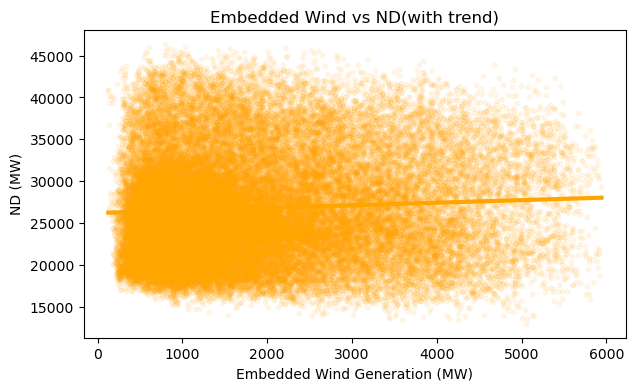

In [7]:

plot_df = df[["EMBEDDED_WIND_GENERATION","ND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(7,4))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_WIND_GENERATION",
    y="ND",
    scatter_kws={"alpha":0.08, "s":10},
    color="orange",
    line_kws={"linewidth":3}
)
plt.title("Embedded Wind vs ND(with trend)")
plt.xlabel("Embedded Wind Generation (MW)")
plt.ylabel("ND (MW)")
# plt.grid(True, alpha=0.3, color="purple)
plt.show()


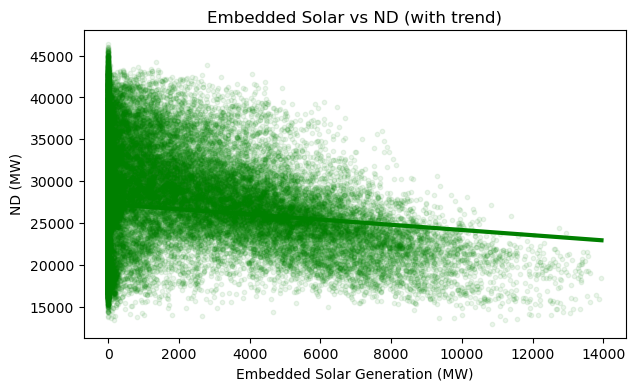

In [8]:
plot_df = df[["EMBEDDED_SOLAR_GENERATION","ND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(7,4))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_SOLAR_GENERATION",
    y="ND",
    scatter_kws={"alpha":0.08, "s":10},
    color="green",
    line_kws={"linewidth":3}
)
plt.title("Embedded Solar vs ND (with trend)")
plt.xlabel("Embedded Solar Generation (MW)")
plt.ylabel("ND (MW)")
#plt.grid(True, alpha=0.3)
plt.show()



/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_4455/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["ND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_4455/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["ND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_4455/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

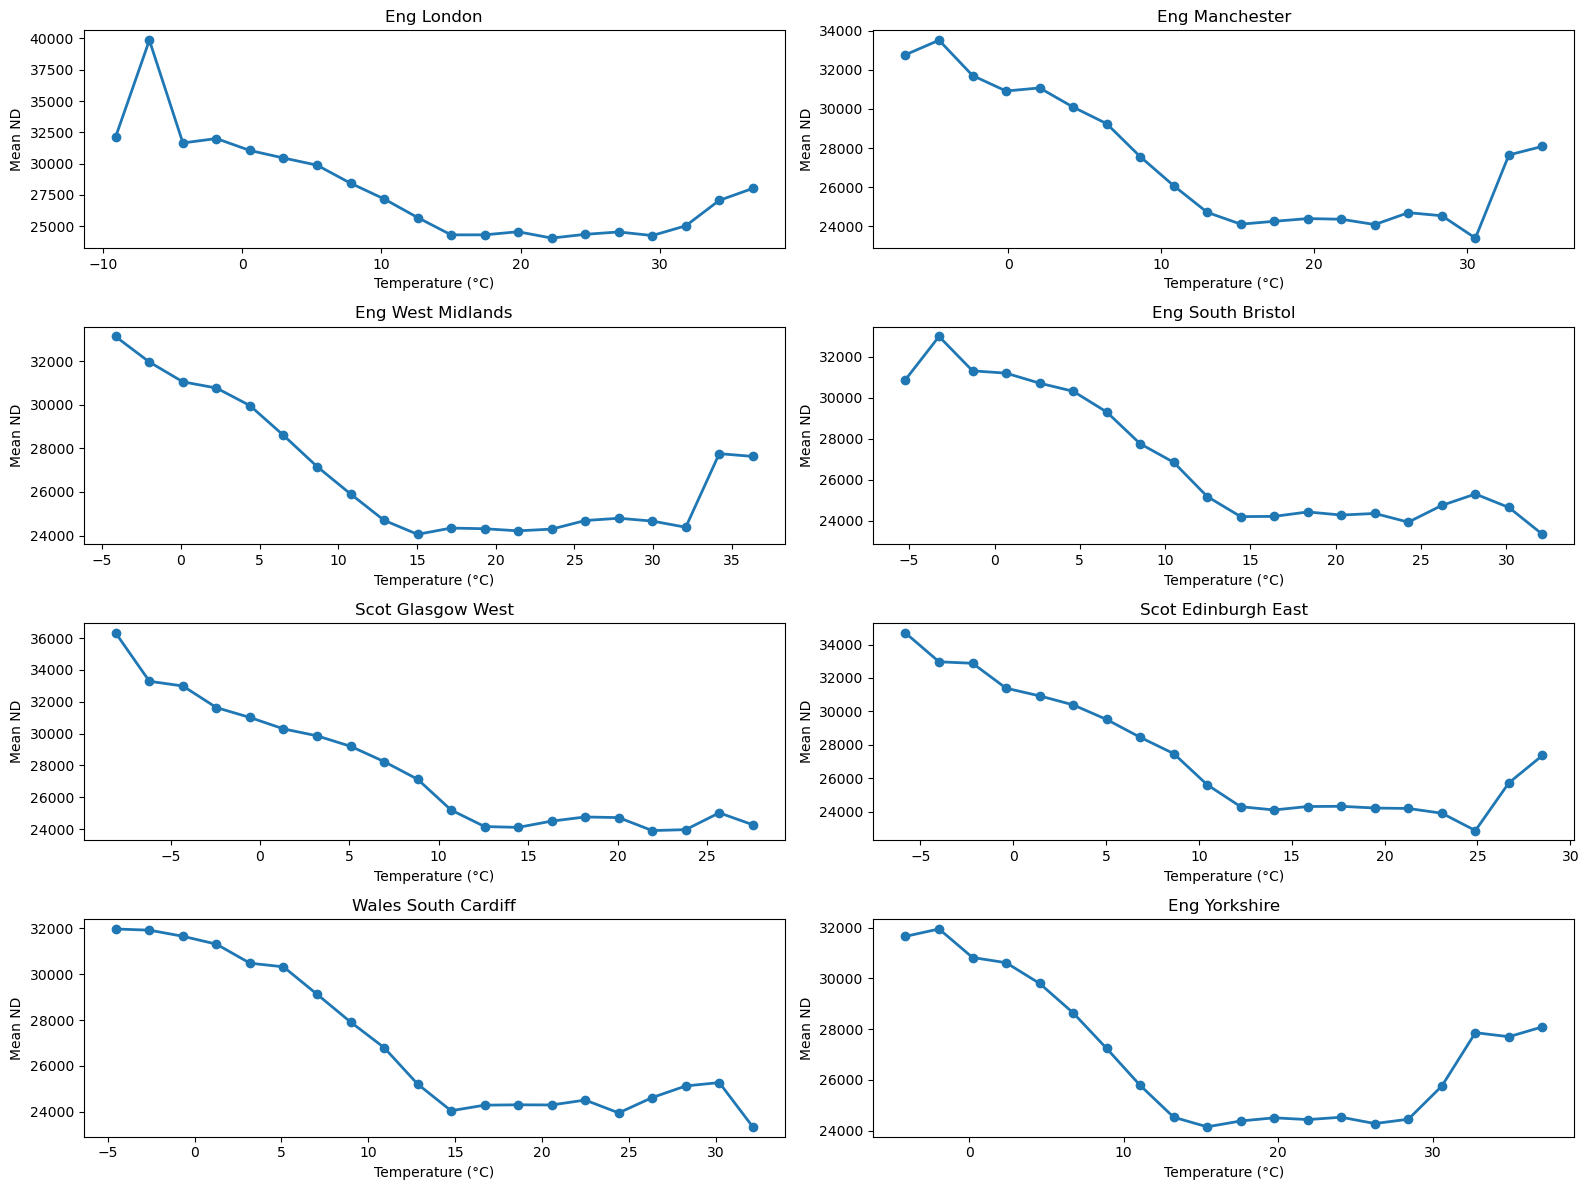

In [9]:


major_temp_cols = [
    "Temp_Eng_London",
    "Temp_Eng_Manchester",
    "Temp_Eng_West_Midlands",
    "Temp_Eng_South_Bristol",
    "Temp_Scot_Glasgow_West",
    "Temp_Scot_Edinburgh_East",
    "Temp_Wales_South_Cardiff",
    "Temp_Eng_Yorkshire"
]

major_temp_cols = [c for c in major_temp_cols if c in df.columns]

plt.figure(figsize=(16, 12))

for i, col in enumerate(major_temp_cols, 1):
    plt.subplot(4, 2, i)

    tmp = df[[col, "ND"]].dropna()

    # bin temperatures (change bins=20 if you want smoother/rougher)
    bins = pd.cut(tmp[col], bins=20)
    mean_nd = tmp.groupby(bins)["ND"].mean()

    # use bin midpoints for x-axis
    x = [b.mid for b in mean_nd.index]

    plt.plot(x, mean_nd.values, marker="o", linewidth=2)
    plt.title(col.replace("Temp_", "").replace("_", " "))
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Mean ND")
    #plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Across all major regions, NET_DEMAND increases as temperature decreases, confirming heating-driven demand. The temperature–demand 
relationship is consistent but varies in strength by region (different slopes), which motivates using regional weather features instead 
of a single national weather value.

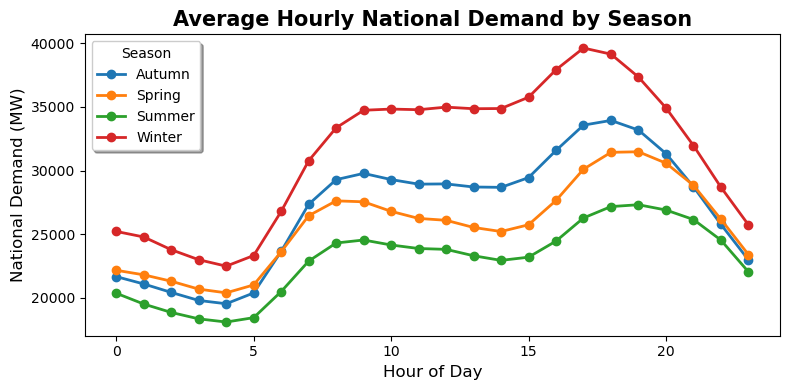

In [10]:

TARGET = "ND"

df_season = df.copy()
df_season["datetime"] = pd.to_datetime(df_season["datetime"], errors='coerce')
df_season = df_season.dropna(subset=["datetime"])

# 2. Extract Hour and Month
df_season["hour"] = df_season["datetime"].dt.hour
df_season["month"] = df_season["datetime"].dt.month

# 3. Create a function to map Months to standard Meteorological Seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Apply the function to create a new 'season' column
df_season["season"] = df_season["month"].apply(get_season)

# 4. Group data to find AVERAGE demand by Season and Hour of the Day
grouped_season = df_season.groupby(["season", "hour"])[TARGET].mean().reset_index()

# ==========================================
# VISUALIZATION SETUP
# ==========================================
plt.figure(figsize=(8, 4))

# Define exact colors to match your uploaded reference image
season_colors = {
    'Autumn': '#1f77b4', # Blue
    'Spring': '#ff7f0e', # Orange
    'Summer': '#2ca02c', # Green
    'Winter': '#d62728'  # Red
}

# Plot each season as a line with circular markers ('o')
for season in ['Autumn', 'Spring', 'Summer', 'Winter']:
    season_data = grouped_season[grouped_season["season"] == season]
    
    plt.plot(season_data["hour"], 
             season_data[TARGET], 
             label=season, 
             marker='o',          # Adds the dots on each hour
             linewidth=2,
             color=season_colors[season])

# ==========================================
# AXIS & LABELS SETUP
# ==========================================
plt.title("Average Hourly National Demand by Season", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("National Demand (MW)", fontsize=12)

# Set x-ticks to match the reference (0, 5, 10, 15, 20)
plt.xticks(range(0, 25, 5))

# Add Legend in the top left
plt.legend(title="Season", loc="upper left", shadow=True)

plt.tight_layout()
plt.show()

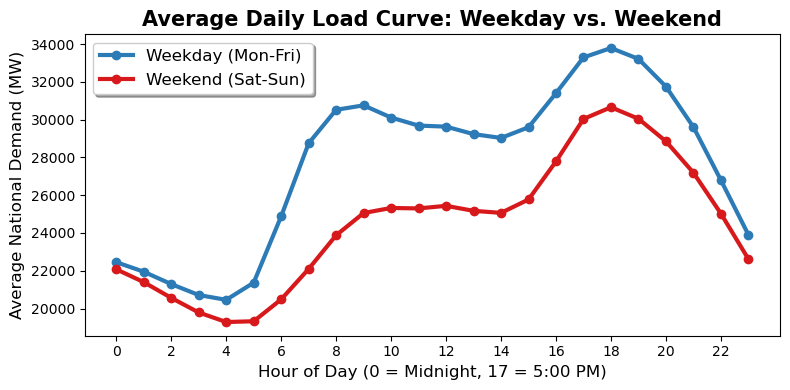

In [11]:

TARGET = "ND"

# 1. Create a fresh copy and ensure datetime is safe
df_daytype = df.copy()
df_daytype["datetime"] = pd.to_datetime(df_daytype["datetime"], errors='coerce')
df_daytype = df_daytype.dropna(subset=["datetime"])

# 2. Extract needed time components
df_daytype["hour"] = df_daytype["datetime"].dt.hour
df_daytype["dayofweek"] = df_daytype["datetime"].dt.dayofweek

# 3. Create a 'Day Type' column (0-4 are Weekdays, 5-6 are Weekends)
df_daytype["Day Type"] = df_daytype["dayofweek"].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 4. Group by Day Type and Hour to get the average demand
grouped_daytype = df_daytype.groupby(["Day Type", "hour"])[TARGET].mean().reset_index()


plt.figure(figsize=(8, 4))

# Plot Weekday
weekday_data = grouped_daytype[grouped_daytype["Day Type"] == 'Weekday']
plt.plot(weekday_data["hour"], 
         weekday_data[TARGET], 
         label='Weekday (Mon-Fri)', 
         color='#2c7bb6', # Professional Blue
         linewidth=3, 
         marker='o')

# Plot Weekend
weekend_data = grouped_daytype[grouped_daytype["Day Type"] == 'Weekend']
plt.plot(weekend_data["hour"], 
         weekend_data[TARGET], 
         label='Weekend (Sat-Sun)', 
         color='#d7191c', # High-Contrast Red
         linewidth=3, 
         marker='o')

# ==========================================
plt.title("Average Daily Load Curve: Weekday vs. Weekend", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day (0 = Midnight, 17 = 5:00 PM)", fontsize=12)
plt.ylabel("Average National Demand (MW)", fontsize=12)

# Show every 2 hours on the x-axis for clean reading
plt.xticks(range(0, 24, 2))


plt.legend(fontsize=12, shadow=True)

plt.tight_layout()
plt.show()

In [12]:
TARGET = "ND"   # change to "ND" or "TSD" if needed

df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

# Medium-Term Lags (Weeks)
df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

# Long-Term Lags (Perfectly aligned by exactly 4 weeks and 52 weeks)
df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

## Why we use Lag-48 and Lag-336

Electricity demand follows strong routines: people wake up, work, cook, and sleep at similar times every day, and weekdays look different from weekends.  
So the demand **at this exact half-hour** is usually close to the demand at the **same half-hour yesterday** and the **same half-hour last week**.

That’s why we add:
- **Lag-48** = demand **24 hours ago** (48 half-hours)
- **Lag-336** = demand **7 days ago** (336 half-hours)

These lag variables act as a strong baseline signal and help models (Linear/Ridge, Random Forest, XGBoost, LSTM) learn the main daily/weekly rhythm, while weather and other features explain the remaining variation (e.g., cold spells, low wind periods, unusual events).


In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
TARGET = "ND"   
H = 24            

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # The formula: mean of |(Actual - Forecast) / Actual| * 100
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# true value we want to predict (tomorrow)
y_true = df[TARGET].shift(-H)

# baseline prediction: tomorrow equals today (exactly 24 hours ago)
y_pred = df[TARGET]

# remove NaNs created by shifting
mask = y_true.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("📈 BASELINE MODEL (Naive Forecast: Tomorrow = Today)")
print("-" * 50)
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))

# ---> THE FIX: Using the correct variables <---
MAPE = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", round(MAPE, 2), "%")

📈 BASELINE MODEL (Naive Forecast: Tomorrow = Today)
--------------------------------------------------
RMSE: 2574.8
MAE : 1836.44
R2  : 0.828
MAPE: 7.04 %


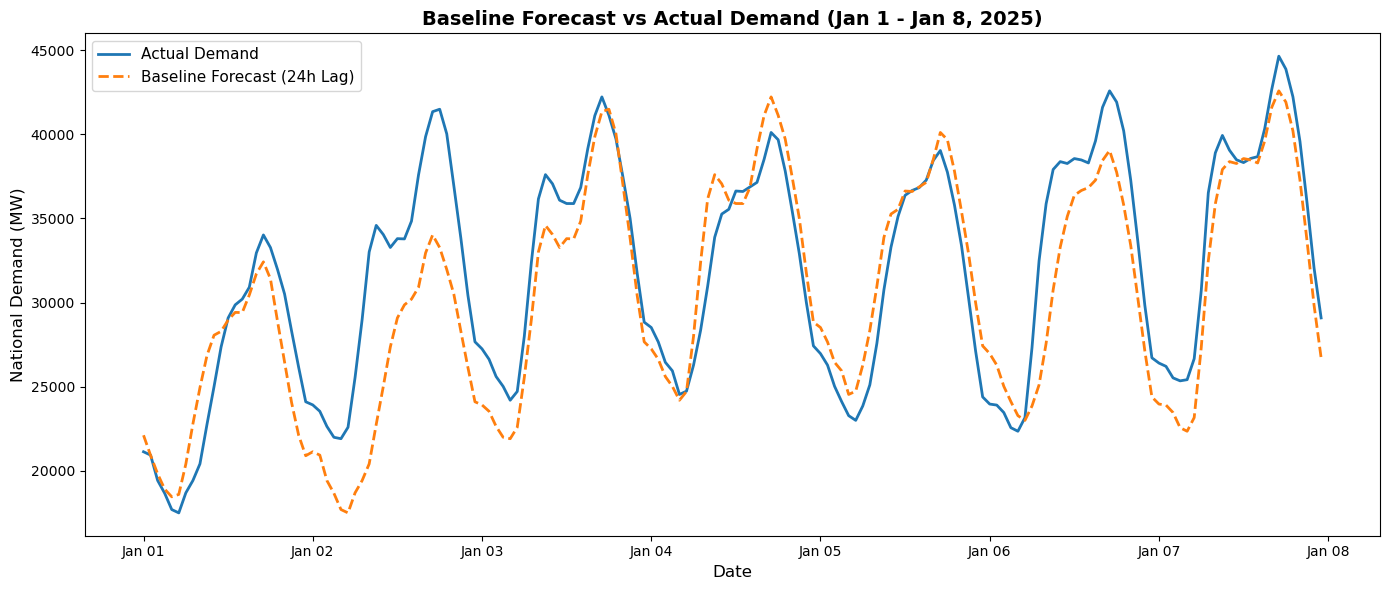

In [21]:

plot_df = pd.DataFrame({
    'datetime': pd.to_datetime(df['datetime']), # Ensure it's a date object
    'Actual': df[TARGET],
    'Predicted': df[TARGET].shift(24) 
})

plot_df.set_index('datetime', inplace=True)
plot_week = plot_df.loc['2025-01-01':'2025-01-07'].copy()
plt.figure(figsize=(14, 6))
plt.plot(plot_week.index, plot_week['Actual'], 
         label="Actual Demand", color='#1f77b4', linewidth=2)
plt.plot(plot_week.index, plot_week['Predicted'], 
         label="Baseline Forecast (24h Lag)", color='#ff7f0e', linestyle="--", linewidth=2)
plt.title("Baseline Forecast vs Actual Demand (Jan 1 - Jan 8, 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel(f"National Demand (MW)", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()

plt.show()

Random Forest

In [ ]:
from typing import List
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = Path(__file__).resolve().parents[2]
DATA_PATH = BASE_DIR / "data/Processed Data/final_model_data.csv"
PREDICTIONS_OUTPUT_PATH = BASE_DIR / "code/RF/outputs/tuned_rf_predictions.csv"
TARGET = "ND"

def mean_abs_error(y_true: List[float], y_pred: List[float]) -> float:
    n = len(y_true)
    sum_err = 0
    for i in range(n):
        if y_true[i] != 0:
            sum_err += abs(y_pred[i] - y_true[i]) / y_true[i]
    return sum_err / n if n > 0 else 0


def build_predictions_frame(
    split_name: str,
    frame: pd.DataFrame,
    actual_values: pd.Series,
    predicted_values: np.ndarray,
) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataset": split_name,
            "datetime": frame["datetime"].values,
            f"actual_{TARGET}": actual_values.values,
            f"predicted_{TARGET}": predicted_values,
        }
    )

def main():
    df = pd.read_csv(DATA_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # CALENDAR-ALIGNED LAGS
    # Short-Term Lags (Days)
    df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
    df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
    df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

    # Medium-Term Lags (Weeks)
    df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
    df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

    # Long-Term Lags (Perfectly aligned by exactly 4 weeks and 52 weeks)
    df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
    df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

    lag_cols = [
        "ND_lag_24", "ND_lag_48", "ND_lag_72", 
        "ND_lag_168", "ND_lag_336", 
        "ND_lag_672", "ND_lag_8736"
    ]

    temp_cols = [c for c in df.columns if c.startswith("Temp_")]
    wind_cols = [c for c in df.columns if c.startswith("Wind10m_")]
    solar_cols = [c for c in df.columns if c.startswith("Solar_")]

    feature_cols = lag_cols + temp_cols + wind_cols + solar_cols
    feature_cols = [c for c in feature_cols if c in df.columns]

    df_model = df.dropna(subset=[TARGET] + lag_cols).copy()

    # Time-based split 
    train_df = df_model[df_model["datetime"] < "2025-01-01"].copy()
    test_df  = df_model[df_model["datetime"] >= "2025-01-01"].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET]
    X_test  = test_df[feature_cols]
    y_test  = test_df[TARGET]

    print("Train rows:", len(train_df), "| Test rows:", len(test_df))
    print("Num features:", len(feature_cols))

    # 1) Hyperparameter search
    tscv = TimeSeriesSplit(n_splits=3)

    param_dist = {
        "n_estimators": [300, 500, 800, 1200],
        "max_depth": [3, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt","log2", 0.3, 0.5],
        "bootstrap": [True]
    }
    base_rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=param_dist,
        n_iter=15,  
        scoring="neg_mean_absolute_error",
        cv=tscv,
        verbose=1,
        n_jobs=1,
        random_state=42
    )

    print("\n⏳ Running hyperparameter tuning (training set only)...")
    search.fit(X_train, y_train)

    print("\n🏆 BEST PARAMETERS:")
    print(search.best_params_)
    print("Best CV MAE:", round(-search.best_score_, 2))

    best_rf = search.best_estimator_

    # 2) Final test evaluation
    pred = best_rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    mape = mean_abs_error(y_test.tolist(), pred.tolist()) * 100

    print("\n✅ TUNED RANDOM FOREST RESULTS (Test 2025):")
    print("RMSE:", round(rmse, 2))
    print("MAE :", round(mae, 2))
    print("R2  :", round(r2, 3))
    print("MAPE:", round(mape, 2), "%")

    # 3) Predict on the Training Data
    train_pred = best_rf.predict(X_train)

    # Calculate Train Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    train_mape = mean_abs_error(y_train.tolist(), train_pred.tolist()) * 100

    print("\n📊 TRAINING DATA RESULTS:")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"MAE : {train_mae:.2f}")
    print(f"R2  : {train_r2:.3f}")
    print(f"MAPE: {train_mape:.2f} %")

    train_predictions_df = build_predictions_frame(
        split_name="train",
        frame=train_df,
        actual_values=y_train,
        predicted_values=train_pred,
    )
    test_predictions_df = build_predictions_frame(
        split_name="test",
        frame=test_df,
        actual_values=y_test,
        predicted_values=pred,
    )
    predictions_df = pd.concat(
        [train_predictions_df, test_predictions_df],
        ignore_index=True,
    )

    PREDICTIONS_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    test_predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH.parent / "test_predictions.csv", index=False)
    predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
    print(f"\nSaved predictions to: {PREDICTIONS_OUTPUT_PATH}")

    # Plot first 7 days of test
    n = min(len(test_df), 24 * 7)  
    plt.figure(figsize=(14, 5))
    plt.plot(test_df["datetime"].iloc[:n], y_test.iloc[:n], label="Actual")
    plt.plot(test_df["datetime"].iloc[:n], pred[:n], label="Tuned RF Pred", linestyle="--")
    plt.title("ND Forecast (Tuned RF) — first 7 days of test")
    plt.xlabel("Datetime")
    plt.ylabel("ND")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

SHAP Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor

DATA_PATH = "data/Processed Data/final_model_data.csv"
TARGET = "ND"

def main():
    print(" Loading data...")
    df = pd.read_csv(DATA_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

     # Short-Term Lags (Days)
    df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
    df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
    df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

    # Medium-Term Lags (Weeks)
    df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
    df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

    # Long-Term Lags 
    df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
    df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

    lag_cols = [
        "ND_lag_24", "ND_lag_48", "ND_lag_72", 
        "ND_lag_168", "ND_lag_336", 
        "ND_lag_672", "ND_lag_8736"
    ]
    temp_cols = [c for c in df.columns if c.startswith("Temp_")]
    wind_cols = [c for c in df.columns if c.startswith("Wind10m_")]
    solar_cols = [c for c in df.columns if c.startswith("Solar_")]

    feature_cols = lag_cols + temp_cols + wind_cols + solar_cols 
    feature_cols = [c for c in feature_cols if c in df.columns]

    df_model = df.dropna(subset=[TARGET] + lag_cols).copy()

    # Train/Test Split
    train_df = df_model[df_model["datetime"] < "2025-01-01"].copy()
    test_df  = df_model[df_model["datetime"] >= "2025-01-01"].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET]
    X_test = test_df[feature_cols]

    print(f" Training Random Forest...")
    rf = RandomForestRegressor(
        n_estimators=1200,
        min_samples_split=2, 
        max_features=0.3,
        max_depth=15, 
        min_samples_leaf=1, 
        bootstrap=True,
        n_jobs=-1, 
        random_state=42
    )
    rf.fit(X_train, y_train)

    #  SHAP ANALYSIS SECTION 🚨
    #  SHAP takes a very long time to run on 40,000 rows.
    # To get plots quickly for the presentation, we randomly sample 500 rows.
    # The statistical insights will be exactly the same.
    print(" Calculating SHAP values... ")
    X_test_sampled = X_test.sample(n=500, random_state=42)
    
    # Create the explainer
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer(X_test_sampled)

    # 1. GLOBAL INTERPRETABILITY: SHAP Summary Plot
    print(" Generating Global SHAP Summary Plot...")
    plt.figure(figsize=(10, 6))
    plt.title("Global Interpretability: How Features Drive Grid Demand")
    shap.summary_plot(shap_values, X_test_sampled, show=False)
    plt.tight_layout()
    plt.show()

    # 2. LOCAL INTERPRETABILITY: SHAP Waterfall Plot
    print(" Generating Local SHAP Waterfall Plot...")
    plt.figure(figsize=(10, 6))
    plt.title("Local Interpretability: Explaining a Single Prediction")
    shap.plots.waterfall(shap_values[0], show=False)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Feature Ablation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

DATA_PATH = "data/Processed Data/final_model_data.csv"
TARGET = "ND"

def main():
    print(" Loading data for Feature Ablation Study...")
    df = pd.read_csv(DATA_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # Short-Term Lags (Days)
    df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
    df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
    df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

    # Medium-Term Lags (Weeks)
    df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
    df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

    # Long-Term Lags 
    df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
    df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

    lag_cols = [
        "ND_lag_24", "ND_lag_48", "ND_lag_72", 
        "ND_lag_168", "ND_lag_336", 
        "ND_lag_672", "ND_lag_8736"
    ]
    temp_cols = [c for c in df.columns if c.startswith("Temp_")]
    wind_cols = [c for c in df.columns if c.startswith("Wind10m_")]
    solar_cols = [c for c in df.columns if c.startswith("Solar_")]
    
    weather_cols = temp_cols + wind_cols + solar_cols
    
    # Define the two different models
    full_features = lag_cols + weather_cols
    full_features = [c for c in full_features if c in df.columns]
    
    ablated_features = lag_cols  # NO WEATHER DATA HERE!
    ablated_features = [c for c in ablated_features if c in df.columns]

    df_model = df.dropna(subset=[TARGET] + lag_cols).copy()

    # Train/Test Split
    train_df = df_model[df_model["datetime"] < "2025-01-01"].copy()
    test_df  = df_model[df_model["datetime"] >= "2025-01-01"].copy()

    y_train = train_df[TARGET]
    y_test = test_df[TARGET]

    print(f" Initializing Random Forest...")
    rf = RandomForestRegressor(
        n_estimators=1200,
        min_samples_split=2, 
        max_features=0.3,
        max_depth=15, 
        min_samples_leaf=1, 
        bootstrap=True,
        n_jobs=-1, 
        random_state=42
    )

    #  RUN 1: THE FULL MODEL
    print(f"\n Training FULL Model (Lags + {len(weather_cols)} Weather Features)...")
    rf.fit(train_df[full_features], y_train)
    pred_full = rf.predict(test_df[full_features])
    mae_full = mean_absolute_error(y_test, pred_full)
    print(f"Full Model MAE: {mae_full:.2f} MW")

    #  RUN 2: THE ABLATED MODEL
    print(f"\n Training ABLATED Model (Lags ONLY, Zero Weather Data)...")
    rf.fit(train_df[ablated_features], y_train)
    pred_ablated = rf.predict(test_df[ablated_features])
    mae_ablated = mean_absolute_error(y_test, pred_ablated)
    print(f"Ablated Model MAE: {mae_ablated:.2f} MW")

    # CALCULATE VALUE AND PLOT
    diff = mae_ablated - mae_full
    
    print("\n" + "="*50)
    print(f"THE VALUE OF WEATHER: Weather data prevents {diff:.2f} MW of error!")
    print("="*50)

    # Create a professional bar chart
    labels = ['Full Model\n(With Weather)', 'Ablated Model\n(No Weather)']
    maes = [mae_full, mae_ablated]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, maes, color=['#2c7bb6', '#d7191c'], edgecolor='black', width=0.5)
    
    plt.title("Feature Ablation: Quantifying the Value of Weather Data", fontsize=14, fontweight='bold')
    plt.ylabel("Mean Absolute Error (MW) - Lower is Better", fontsize=12)
    plt.ylim(0, max(maes) * 1.2)

    # Add the MAE numbers on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 15, f'{yval:.0f} MW', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Add a highlight box showing the exact value
    plt.text(0.5, max(maes) * 1.05, f"Adding weather features reduces\nforecasting error by {diff:.0f} Megawatts", 
             ha='center', va='center', fontsize=12, bbox=dict(facecolor='#ffffcc', alpha=0.8, edgecolor='black'))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Feature Importance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. SETUP AND DATA LOADING
DATA_PATH = "data/Processed Data/final_model_data.csv"
TARGET = "ND"

def main():
    print(" Loading data and engineering features...")
    df = pd.read_csv(DATA_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # Short-Term Lags (Days)
    df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
    df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
    df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

    # Medium-Term Lags (Weeks)
    df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
    df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

    # Long-Term Lags (Perfectly aligned by exactly 4 weeks and 52 weeks)
    df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
    df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

    lag_cols = [
        "ND_lag_24", "ND_lag_48", "ND_lag_72", 
        "ND_lag_168", "ND_lag_336", 
        "ND_lag_672", "ND_lag_8736"
    ]
    temp_cols = [c for c in df.columns if c.startswith("Temp_")]
    wind_cols = [c for c in df.columns if c.startswith("Wind10m_")]
    solar_cols = [c for c in df.columns if c.startswith("Solar_")]

    feature_cols = lag_cols + temp_cols + wind_cols + solar_cols 
    feature_cols = [c for c in feature_cols if c in df.columns]

    # Drop missing rows
    df_model = df.dropna(subset=[TARGET] + lag_cols).copy()

    # 2. TRAIN THE MODEL (Using Training Data Only)
    # We only need to train the model to get feature importances. 
    # We use the training set (pre-2025) to prevent any data leakage.
    train_df = df_model[df_model["datetime"] < "2025-01-01"].copy()
    
    X_train = train_df[feature_cols]
    y_train = train_df[TARGET]

    print(f" Training Random Forest on {len(X_train)} rows to calculate importance...")
    
    # Using the tuned parameters
    rf = RandomForestRegressor(
        n_estimators=1200,
        min_samples_split=2, 
        max_features=0.3,
        max_depth=15, 
        min_samples_leaf=1, 
        bootstrap=True,
        n_jobs=-1, 
        random_state=42
    )

    rf.fit(X_train, y_train)

    # 3. EXTRACT AND PLOT FEATURE IMPORTANCES
    print(" Generating Feature Importance Plot...")
    
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1] # Sort from highest to lowest

    # Get the top 15 features so the chart isn't overly crowded
    top_n = 15
    top_indices = indices[:top_n]
    
    plt.figure(figsize=(12, 6))
    plt.title(f"Top {top_n} Drivers of UK Grid Demand (Random Forest Global Importance)", fontsize=14, fontweight='bold')
    
    # Create the bar chart
    bars = plt.bar(
        range(top_n), 
        importances[top_indices], 
        align="center", 
        color="#2c7bb6", 
        edgecolor="black"
    )
    
    # Label the x-axis with the actual feature names
    plt.xticks(
        range(top_n), 
        [feature_cols[i] for i in top_indices], 
        rotation=45, 
        ha="right",
        fontsize=10
    )
    
    plt.ylabel("Relative Importance Score (Gini)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', va='bottom', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Error Analaysis

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path

# --- Setup Paths ---
BASE_DIR = Path(__file__).resolve().parents[2]
RAW_DATA_PATH = BASE_DIR / "data/Processed Data/final_model_data.csv"
PREDICTIONS_PATH = BASE_DIR / "code/RF/outputs/test_predictions.csv"

def main():
    print(" Loading data for Analysis...")
    
    # PART 1: LAG BEHAVIOR (Autocorrelation)
    print(" Generating Autocorrelation Plot...")
    df_raw = pd.read_csv(RAW_DATA_PATH)
    
    plt.figure(figsize=(12, 5))
    # Look back 200 hours to capture the 24h and 168h cycles
    plot_acf(df_raw["ND"].dropna(), lags=200, alpha=0.05, title="Autocorrelation of National Demand (Lag Behavior)")
    plt.xlabel("Lag (Hours)")
    plt.ylabel("Correlation Coefficient")

    # Highlight the specific lags we engineered
    plt.axvline(x=24, color='r', linestyle='--', alpha=0.7, label='24h (Daily Routine)')
    plt.axvline(x=168, color='g', linestyle='--', alpha=0.7, label='168h (Weekly Routine)')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() 

    # PART 2: VISUAL ERROR ANALYSIS
    print(" Generating Visual Error Analysis...")
    
    try:
        results_df = pd.read_csv(PREDICTIONS_PATH)
    except FileNotFoundError:
        print(f" Could not find {PREDICTIONS_PATH}.")
        return

    # Convert datetime back to timestamp objects
    results_df['datetime'] = pd.to_datetime(results_df['datetime'])
    
    # Calculate Absolute Error
    results_df['Absolute_Error'] = abs(results_df['actual_ND'] - results_df['predicted_ND'])

    # Extract time features for plotting
    results_df['hour'] = results_df['datetime'].dt.hour
    results_df['dayofweek'] = results_df['datetime'].dt.dayofweek # 0=Mon, 6=Sun

    # Setup the canvas for two side-by-side bar charts
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot A: Error by Hour
    sns.barplot(data=results_df, x='hour', y='Absolute_Error', ax=axes[0], color='#1f77b4')
    axes[0].set_title('Average Forecasting Error by Hour of Day', fontweight='bold')
    axes[0].set_xlabel('Hour of Day (0 = Midnight)')
    axes[0].set_ylabel('Absolute Error (MW)')

    # Plot B: Error by Day of Week
    sns.barplot(data=results_df, x='dayofweek', y='Absolute_Error', ax=axes[1], color='#ff7f0e')
    axes[1].set_title('Average Forecasting Error by Day of Week', fontweight='bold')
    axes[1].set_xlabel('Day of Week (0 = Monday, 6 = Sunday)')
    axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    axes[1].set_ylabel('Absolute Error (MW)')

    plt.tight_layout()
    plt.show()

    # PART 3: FIND THE WORST PREDICTION
    worst_idx = results_df['Absolute_Error'].idxmax()
    worst_day = results_df.loc[worst_idx]
    
    print(f"\n WORST SINGLE PREDICTION OF 2025:")
    print(f"Time: {worst_day['datetime']}")
    print(f"Actual: {round(worst_day['actual_ND'], 1)} MW")
    print(f"Predicted: {round(worst_day['predicted_ND'], 1)} MW")
    print(f"Error Magnitude: {round(worst_day['Absolute_Error'], 1)} MW")

if __name__ == "__main__":
    main()

XG Boost

In [ ]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_PATH = "data/processed/final_model_data.csv"
TARGET = "ND"
TRAIN_CUTOFF = "2025-01-01"
EARLY_STOPPING_ROUNDS = 50
MAX_BOOSTING_ROUNDS = 2000
VAL_FRACTION = 0.10

WEATHER_COLS = [
    "Temp_Scot_Highlands", "Wind10m_Scot_Highlands",
    "Temp_Scot_Aberdeenshire", "Wind10m_Scot_Aberdeenshire",
    "Temp_Scot_Glasgow_West", "Temp_Scot_Edinburgh_East",
    "Temp_Scot_Borders", "Wind10m_Scot_Borders",
    "Temp_Wales_North_Gwynedd", "Wind10m_Wales_North_Gwynedd",
    "Temp_Wales_South_Cardiff",
    "Temp_Eng_North_Tyne", "Temp_Eng_North_Cumbria", "Wind10m_Eng_North_Cumbria",
    "Temp_Eng_Yorkshire", "Wind10m_Eng_Yorkshire",
    "Temp_Eng_Manchester", "Temp_Eng_West_Midlands",
    "Temp_Eng_East_Midlands", "Solar_Eng_East_Midlands",
    "Temp_Eng_East_Norfolk", "Wind10m_Eng_East_Norfolk", "Solar_Eng_East_Norfolk",
    "Temp_Eng_East_Suffolk", "Wind10m_Eng_East_Suffolk", "Solar_Eng_East_Suffolk",
    "Temp_Eng_London", "Solar_Eng_London",
    "Temp_Eng_South_Kent", "Solar_Eng_South_Kent",
    "Temp_Eng_South_Hampshire", "Solar_Eng_South_Hampshire",
    "Temp_Eng_South_Cornwall", "Solar_Eng_South_Cornwall",
    "Temp_Eng_South_Bristol", "Solar_Eng_South_Bristol",
]

LAG_HOURS = [24, 48, 72, 168]
ROLLING_WINDOWS = [24, 48, 168]

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    return {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "MAPE": round(mape, 4),
    }

def _add_time_features(df):
    df = df.copy()
    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month
    df["day_of_year"] = df["datetime"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df

def _add_lag_features(df, target_col="ND", lags=LAG_HOURS):
    df = df.copy()
    for lag in lags:
        df[f"{target_col}_lag_{lag}h"] = df[target_col].shift(lag)
    return df

def _add_rolling_features(df, target_col="ND", windows=ROLLING_WINDOWS):
    df = df.copy()
    for w in windows:
        df[f"{target_col}_rmean_{w}h"] = df[target_col].shift(24).rolling(w).mean()
        df[f"{target_col}_rstd_{w}h"] = df[target_col].shift(24).rolling(w).std()
    return df

def prepare_model_frame(df, include_weather=True, target_col="ND", lag_hours=None, rolling_windows=None):
    if lag_hours is None:
        lag_hours = LAG_HOURS
    if rolling_windows is None:
        rolling_windows = ROLLING_WINDOWS
    
    df = _add_time_features(df)
    df = _add_lag_features(df, target_col=target_col, lags=lag_hours)
    df = _add_rolling_features(df, target_col=target_col, windows=rolling_windows)
    
    time_features = [
        "hour", "day_of_week", "month", "day_of_year", "is_weekend",
        "hour_sin", "hour_cos", "month_sin", "month_cos",
    ]
    lag_features = [f"{target_col}_lag_{lag}h" for lag in lag_hours]
    rolling_features = [
        f"{target_col}_{stat}_{w}h"
        for w in rolling_windows for stat in ["rmean", "rstd"]
    ]
    
    feature_cols = time_features + lag_features + rolling_features
    
    if include_weather:
        weather_lag = 24
        lagged_weather_cols = {}
        for col in WEATHER_COLS:
            if col in df.columns:
                lagged_weather_cols[f"{col}_lag_{weather_lag}h"] = df[col].shift(weather_lag)
        if lagged_weather_cols:
            df = pd.concat([df, pd.DataFrame(lagged_weather_cols)], axis=1)
        lagged_weather = list(lagged_weather_cols.keys())
        feature_cols += lagged_weather
        
    keep_cols = ["datetime", target_col] + feature_cols
    df_model = df[keep_cols].dropna().reset_index(drop=True)
    return df_model, feature_cols

def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.sort_values("datetime").reset_index(drop=True)

def prepare_xgboost_data(df):
    df_model, feature_cols = prepare_model_frame(df, include_weather=True, target_col=TARGET)
    train_df = df_model[df_model["datetime"] < TRAIN_CUTOFF].copy()
    test_df = df_model[df_model["datetime"] >= TRAIN_CUTOFF].copy()
    return train_df[feature_cols], test_df[feature_cols], train_df[TARGET], test_df[TARGET], train_df, test_df, feature_cols

def run_full_pipeline(path=DATA_PATH):
    df = load_data(path)
    X_train, X_test, y_train, y_test, train_df, test_df, feature_cols = prepare_xgboost_data(df)

    best_params = {
        "max_depth": 6,
        "learning_rate": 0.015,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "min_child_weight": 5,
        "gamma": 0.1,
        "reg_alpha": 0.5,
        "reg_lambda": 3.0
    }

    split_idx = int(len(X_train) * (1 - VAL_FRACTION))
    X_fit, y_fit = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
    X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_estimators=MAX_BOOSTING_ROUNDS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=42,
        verbosity=0,
        **best_params
    )
    
    model.fit(X_fit, y_fit, eval_set=[(X_fit, y_fit), (X_val, y_val)], verbose=False)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_metrics = evaluate_regression(y_train.values, y_pred_train)
    test_metrics = evaluate_regression(y_test.values, y_pred_test)

    print("\n" + "="*50)
    print("XGBOOST HYPERPARAMETERS USED:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    print("="*50)
    
    print("\nTRAINING DATA RESULTS:")
    print(f"RMSE: {train_metrics['RMSE']:.2f}")
    print(f"MAE : {train_metrics['MAE']:.2f}")
    print(f"R2  : {train_metrics['R2']:.3f}")
    print(f"MAPE: {train_metrics['MAPE']:.2f} %")
    
    print("\nDAY-AHEAD XGBOOST RESULTS (Test 2025):")
    print(f"RMSE: {test_metrics['RMSE']:.2f}")
    print(f"MAE : {test_metrics['MAE']:.2f}")
    print(f"R2  : {test_metrics['R2']:.3f}")
    print(f"MAPE: {test_metrics['MAPE']:.2f} %")
    print("="*50 + "\n")

    Path("data/processed").mkdir(parents=True, exist_ok=True)
    Path("figures").mkdir(parents=True, exist_ok=True)
    
    pd.DataFrame({
        "datetime": test_df["datetime"].values, 
        "actual_ND": y_test.values, 
        "predicted_ND": y_pred_test
    }).to_csv("data/processed/xgb_test_predictions.csv", index=False)

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    top_n = 20
    top = importance_df.head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(top)))
    
    ax.barh(top["feature"], top["importance"], color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Importance (Gain)", fontsize=11)
    ax.set_title(f"XGBoost Day-Ahead: Top {top_n} Feature Importances", fontsize=13, fontweight="bold", pad=12)
    ax.grid(True, axis="x", alpha=0.3)

    for i, (_, row) in enumerate(top.iterrows()):
        ax.text(
            row["importance"] + importance_df["importance"].max() * 0.01,
            i, 
            f'{row["importance"]:.4f}', 
            va="center", 
            fontsize=8, 
            color="#333"
        )

    plt.tight_layout()
    fig.savefig("figures/xgb_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

if __name__ == "__main__":
    run_full_pipeline()

: 

LSTM GWO

In [ ]:
import numpy as np
import pandas as pd
import gc
import os
import random
import tensorflow as tf
from tensorflow import keras #type:ignore
from tensorflow.keras import backend as K #type:ignore
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout #type:ignore

def build_advanced_lstm(input_shape, units, dropout, lr, num_layers, activation_idx):
    """Builds a stacked LSTM based on GWO discovered parameters."""
    activations = ['relu', 'tanh', 'sigmoid']
    selected_act = activations[int(activation_idx)] 
    
    model = Sequential()
    for i in range(int(num_layers)):
        is_last_layer = (i == int(num_layers) - 1)
        if i == 0:
            model.add(LSTM(units=int(units), activation=selected_act, 
                           return_sequences=not is_last_layer, input_shape=input_shape))
        else:
            model.add(LSTM(units=int(units), activation=selected_act, 
                           return_sequences=not is_last_layer))
        model.add(Dropout(dropout))
    
    model.add(Dense(1))
    # Note: Compiling with MSE here. If you want to strictly optimize for MAPE, change loss='mse' to loss='mape'
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

def tune_lstm_with_gwo_advanced(X_train_2d, y_train, X_test_2d, y_test, n_wolves=5, iterations=30, seed=42):
    
    # --- 0. LOCK DOWN DETERMINISM ---
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # 1. Reshape FULL Data for LSTM (No downsampling)
    X_train_3d = np.reshape(X_train_2d, (X_train_2d.shape[0], 1, X_train_2d.shape[1]))
    X_test_3d = np.reshape(X_test_2d, (X_test_2d.shape[0], 1, X_test_2d.shape[1]))
    in_shape = (X_train_3d.shape[1], X_train_3d.shape[2])

    # 2. Search Space: [Units, Dropout, LR, Layers, Act_Idx]
    lb = np.array([16, 0.0, 0.0001, 1, 0])
    ub = np.array([256, 0.5, 0.01, 4, 2])
    dim = 5
    
    # Initialize wolves
    wolves = np.random.uniform(lb, ub, (n_wolves, dim))
    
    # SNAP TO GRID during initialization for discrete variables
    wolves[:, 3] = np.round(wolves[:, 3]) # Layers
    wolves[:, 4] = np.round(wolves[:, 4]) # Activation Index

    alpha_pos, alpha_score = np.zeros(dim), float('inf')
    beta_pos, beta_score = np.zeros(dim), float('inf')
    delta_pos, delta_score = np.zeros(dim), float('inf')

    print(f"Starting GWO Optimization on FULL {len(X_train_3d)} sequences...")

    for t in range(iterations):
        print(f"--- Iteration {t+1}/{iterations} ---")
        for i in range(n_wolves):
            # Clip bounds BEFORE evaluation
            wolves[i] = np.clip(wolves[i], lb, ub)
            p = wolves[i]
            
            # Brief training to evaluate fitness
            model = build_advanced_lstm(in_shape, p[0], p[1], p[2], p[3], p[4])
            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=3, restore_best_weights=True
            )
            
            # Train on the FULL dataset
            hist = model.fit(X_train_3d, y_train, validation_split=0.2,
                             epochs=20, batch_size= 64, verbose=0, callbacks=[early_stop])
            
            # Fitness evaluation
            fitness = min(hist.history['val_loss'])

            # Update Alpha, Beta, Delta
            if fitness < alpha_score:
                alpha_score, alpha_pos = fitness, wolves[i].copy()
            elif fitness < beta_score:
                beta_score, beta_pos = fitness, wolves[i].copy()
            elif fitness < delta_score:
                delta_score, delta_pos = fitness, wolves[i].copy()

            # --- CRITICAL MEMORY LEAK FIX ---
            del model
            K.clear_session()
            gc.collect()

        # Checkpoint to disk after every iteration
        pd.DataFrame([alpha_pos], columns=['Units', 'Dropout', 'LR', 'Layers', 'Act_Idx']).to_csv('gwo_checkpoint.csv', index=False)

        # Update Wolf Positions (Standard GWO Logic + Discrete Snapping)
        a = 2 - t * (2 / iterations)
        for i in range(n_wolves):
            for j in range(dim):
                r1, r2 = np.random.random(), np.random.random()
                A1, C1 = 2*a*r1-a, 2*r2
                X1 = alpha_pos[j] - A1 * abs(C1 * alpha_pos[j] - wolves[i,j])
                
                r1, r2 = np.random.random(), np.random.random()
                A2, C2 = 2*a*r1-a, 2*r2
                X2 = beta_pos[j] - A2 * abs(C2 * beta_pos[j] - wolves[i,j])
                
                r1, r2 = np.random.random(), np.random.random()
                A3, C3 = 2*a*r1-a, 2*r2
                X3 = delta_pos[j] - A3 * abs(C3 * delta_pos[j] - wolves[i,j])
                
                new_pos = (X1 + X2 + X3) / 3

                # SNAP TO GRID during position update
                if j in [3, 4]:
                    wolves[i,j] = round(new_pos)
                else:
                    wolves[i,j] = new_pos

    # 3. Final Training and Predictions
    print(f"\nOptimization Complete. Best Parameters: Units={int(alpha_pos[0])}, Dropout={alpha_pos[1]:.2f}, LR={alpha_pos[2]:.4f}, Layers={int(alpha_pos[3])}, Act_Idx={int(alpha_pos[4])}")
    print("Training Final Model with Best Parameters...")
    
    best_model = build_advanced_lstm(in_shape, *alpha_pos)
    best_model.fit(X_train_3d, y_train, epochs=50, validation_split=0.2, 
                   callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)], 
                   verbose=1)
    
    y_train_pred = best_model.predict(X_train_3d)
    y_test_pred = best_model.predict(X_test_3d)
    
    return best_model, alpha_pos, y_train_pred, y_test_pred, X_train_3d, X_test_3d

In [ ]:
from typing import List
import os
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle
import tensorflow as tf

version_num = '6.0'

def set_global_determinism(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

set_global_determinism(seed=42)

# 1. Load and Clean Data
df_original = pd.read_csv("./data/final_model_data.csv")
columns_drop = ['TSD', 'ENGLAND_WALES_DEMAND','EMBEDDED_WIND_GENERATION',
    'EMBEDDED_WIND_CAPACITY','EMBEDDED_SOLAR_GENERATION','EMBEDDED_SOLAR_CAPACITY',
    'NON_BM_STOR','PUMP_STORAGE_PUMPING','NET_IMPORTS','SCOTTISH_TRANSFER', 'datetime']

df = df_original.drop(columns=columns_drop)

data = df.values
scaler = MinMaxScaler(feature_range=(0,1))

# --- Configuration ---
target_col_index = 0
time_steps = [24, 48, 72, 7*24, 30*24, 24*365]

# 2. Sequential Train/Test Split
split_idx = int(len(data) * 0.8)

train_data = data[:split_idx]
test_data = data[split_idx:]

# 3. Scale Data
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

with open('minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved successfully to 'minmax_scaler.pkl'")

# 4. Sequence Generation Function
def create_y_lags_2d(dataset, target_index, lags):
    X, y = [], []
    max_lag = max(lags)
    sorted_lags = sorted(lags, reverse=True)
    
    for i in range(max_lag, len(dataset)):
        current_weather_features = np.delete(dataset[i], target_index)
        lagged_y_features = [dataset[i - lag, target_index] for lag in sorted_lags]
        combined_features = np.concatenate([current_weather_features, lagged_y_features])
        
        X.append(combined_features)
        y.append(dataset[i, target_index])
        
    return np.array(X), np.array(y)

# 5. Build Tensors
X_train, y_train = create_y_lags_2d(train_data_scaled, target_col_index, time_steps)
X_test, y_test = create_y_lags_2d(test_data_scaled, target_col_index, time_steps)

print("--- Tensor Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

# 6. Run Tuner (Downsampling handled internally)
final_model, params, y_train_pred, y_test_pred, X_train_3d, X_test_3d = tune_lstm_with_gwo_advanced(
    X_train, y_train, X_test, y_test
)

# 7. Unscale Predictions
def inverse_transform_target(scaled_1d_array, scaler, target_index, n_features):
    dummy_matrix = np.zeros((len(scaled_1d_array), n_features))
    dummy_matrix[:, target_index] = scaled_1d_array.flatten()
    unscaled_matrix = scaler.inverse_transform(dummy_matrix)
    return unscaled_matrix[:, target_index]

def mean_abs_error(y_true : List[float], y_pred: List[float]) -> float:
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

num_features = train_data.shape[1]

y_train_unscaled = inverse_transform_target(y_train, scaler, target_col_index, num_features)
y_train_pred_unscaled = inverse_transform_target(y_train_pred, scaler, target_col_index, num_features)
y_test_unscaled = inverse_transform_target(y_test, scaler, target_col_index, num_features)
y_test_pred_unscaled = inverse_transform_target(y_test_pred, scaler, target_col_index, num_features)

mape_train = mean_abs_error(y_train_unscaled, y_train_pred_unscaled)
mape_test = mean_abs_error(y_test_unscaled, y_test_pred_unscaled)

print("MAPE training: ", mape_train)
print("MAPE test: ", mape_test)

final_model.save(f'GWO_best_model_v{version_num}.keras')

# 8. Align Datetime Indices
max_lag = 365 * 24
split_idx = int(len(df_original) * 0.8)

train_dates = df_original['datetime'].iloc[max_lag : split_idx].values
test_dates = df_original['datetime'].iloc[split_idx + max_lag : ].values

train_results_df = pd.DataFrame({
    'Datetime': train_dates,
    'Actual_Train': y_train_unscaled.flatten(),
    'Predicted_Train': y_train_pred_unscaled.flatten()
})
train_results_df.to_csv(f'LSTM_GWO_training_results_with_dates_v{version_num}.csv', index=False)
print("Training results with dates successfully saved!")

test_results_df = pd.DataFrame({
    'Datetime': test_dates,
    'Actual_Test': y_test_unscaled.flatten(),
    'Predicted_Test': y_test_pred_unscaled.flatten()
})
test_results_df.to_csv(f'LSTM_GWO_testing_results_with_dates_v{version_num}.csv', index=False)
print("Testing results with dates successfully saved!")

Feature Importance


In [ ]:
import pandas as pd
import tensorflow as tf
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


def run_permutation_importance(model, X_test_3d, y_test, feature_names):
    print("Calculating baseline performance...")
    
    # 1. Get Baseline Error (Fixed the tuple bug here)
    baseline_preds = model.predict(X_test_3d, verbose=0)
    baseline_mape = mean_absolute_error(y_test.flatten(), baseline_preds.flatten())
    print(f"Baseline Test MAE: {baseline_mape:.4f}\n")

    importances = []
    num_features = X_test_3d.shape[2] 

    print("Running permutation tests (this may take a minute)...")
    for i in range(num_features):
        X_test_shuffled = X_test_3d.copy()
        
        # Shuffle ONLY the current feature
        np.random.shuffle(X_test_shuffled[:, 0, i])
        
        # Predict with sabotaged feature
        shuffled_preds = model.predict(X_test_shuffled, verbose=0)
        shuffled_mape = mean_absolute_error(y_test.flatten(), shuffled_preds.flatten())
        
        importance_score = shuffled_mape - baseline_mape
        importances.append(importance_score)
        
        print(f"Sabotaged {feature_names[i]}: New MAE = {shuffled_mape:.4f} (+{importance_score:.4f})")

    results_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Score_MAE_Increase': importances
    })
    
    # Sort ascending (least important at the top of the dataframe, most important at the bottom)
    results_df = results_df.sort_values(by='Importance_Score_MAE_Increase', ascending=True)
    
    # --- NEW: Extract only the top 10 most important features for the plot ---
    top_10_df = results_df.tail(15)
    
    # 3. Plot the Results
    plt.figure(figsize=(10, 6)) # Reduced height since there are fewer bars
    plt.barh(top_10_df['Feature'], top_10_df['Importance_Score_MAE_Increase'], color='darkred')
    
    # Add data labels to the bars for a more professional look
    for index, value in enumerate(top_10_df['Importance_Score_MAE_Increase']):
        plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

    plt.xlabel('Increase in Error (MAE) when feature is shuffled')
    plt.title('Top 10 LSTM Permutation Feature Importances')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Pad the x-axis limits slightly so the text labels don't get cut off
    plt.xlim(0, top_10_df['Importance_Score_MAE_Increase'].max() * 1.15)
    
    plt.tight_layout()
    plt.savefig('LSTM_Top10_Feature_Importance.png', dpi=300)
    plt.show()

    # Still return the full dataframe so your CSV saves all 43 features
    return results_df

if __name__ == "__main__":
    # --- 1. Load Data ---
    print("Loading data...")
    df_original = pd.read_csv("./data/final_model_data.csv")
    columns_drop = ['TSD', 'ENGLAND_WALES_DEMAND','EMBEDDED_WIND_GENERATION',
        'EMBEDDED_WIND_CAPACITY','EMBEDDED_SOLAR_GENERATION','EMBEDDED_SOLAR_CAPACITY',
        'NON_BM_STOR','PUMP_STORAGE_PUMPING','NET_IMPORTS','SCOTTISH_TRANSFER', 'datetime']

    feature_list = ['Temp_Scot_Highlands','Wind10m_Scot_Highlands','Temp_Scot_Aberdeenshire',
        'Wind10m_Scot_Aberdeenshire','Temp_Scot_Glasgow_West','Temp_Scot_Edinburgh_East',
        'Temp_Scot_Borders','Wind10m_Scot_Borders','Temp_Wales_North_Gwynedd',
        'Wind10m_Wales_North_Gwynedd','Temp_Wales_South_Cardiff','Temp_Eng_North_Tyne',
        'Temp_Eng_North_Cumbria','Wind10m_Eng_North_Cumbria','Temp_Eng_Yorkshire',
        'Wind10m_Eng_Yorkshire','Temp_Eng_Manchester','Temp_Eng_West_Midlands',
        'Temp_Eng_East_Midlands','Solar_Eng_East_Midlands','Temp_Eng_East_Norfolk',
        'Wind10m_Eng_East_Norfolk','Solar_Eng_East_Norfolk','Temp_Eng_East_Suffolk',
        'Wind10m_Eng_East_Suffolk','Solar_Eng_East_Suffolk','Temp_Eng_London',
        'Solar_Eng_London','Temp_Eng_South_Kent','Solar_Eng_South_Kent',
        'Temp_Eng_South_Hampshire','Solar_Eng_South_Hampshire','Temp_Eng_South_Cornwall',
        'Solar_Eng_South_Cornwall','Temp_Eng_South_Bristol','Solar_Eng_South_Bristol',
        'lag_3','lag_6','lag_12','lag_24','lag_48','lag_3m','lag_8760']

    df = df_original.drop(columns=columns_drop)
    data = df.values

    # --- 2. Split First ---
    split_idx = int(len(data) * 0.8)
    test_data = data[split_idx:]

    # --- 3. Scale Second ---
    with open('minmax_scaler.pkl', 'rb') as f:
        scaler = pk.load(f)
    print("Scaler loaded successfully.")

    test_data_scaled = scaler.transform(test_data)

    # --- 4. Generate Lags Third ---
    target_col_index = 0
    # time_steps = [24, 48, 72, 7*24, 30*24, 24*365]
    time_steps = [3, 6, 12, 24, 48, 3*30*24, 24*365]

    print("Generating lags...")
    X_test_scaled, y_test_scaled = create_y_lags_2d(test_data_scaled, target_col_index, time_steps)
    X_test_3d = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    # Sanity Check
    assert len(feature_list) == X_test_3d.shape[2], f"CRITICAL: You listed {len(feature_list)} features, but the model expects {X_test_3d.shape[2]}."

    # --- 5. Load Model and Execute ---
    champion_model = tf.keras.models.load_model('GWO_best_model.keras')
    print("Model loaded successfully. Running Permutation Importance...")

    results_df = run_permutation_importance(champion_model, X_test_3d, y_test_scaled, feature_list)

    results_df.to_csv('./feature_importance_results.csv', index=False)
    print("Results saved successfully.")